**Problem 5**: Now that we can derive transfer functions for physical systems, we would like to understand how those systems behave under feedback control. Rather than solving the differential equation every time, is there a simpler way to predict rise time, settling time, oscillation, overshoot, and stability directly from the transfer function? Furthermore, how does PID control modify this behaviour?

Consider a motor with the transfer function:
$$ P(s) = \dfrac{K}{\tau s + 1}$$
First, we will see how the system naturally behaves. We already know that the DC gain is $P(0) = K$, and the time constant is $\tau$. This means that the system takes $\tau$ units of time, in this case let's use seconds, to settle. 

Now let's analyse this. We know that $s = \sigma + j \omega$, which is a variable in the complex plane. Giving it an arbitrary voltage signal yields:
$$ \Omega(s) = \dfrac{K V(s)}{\tau s + 1}$$
Rewriting it as
$$ \Omega(s) = \dfrac{K}{\tau} . \dfrac{1}{s + \frac{1}{\tau}} V(s)$$
we can now take the inverse Laplace transform. Recall that the convolution theorem states that:
$$\mathcal{L}^{-1}(FG) = f * g$$
Therefore:
$$ \omega(t) = \dfrac{K}{\tau} e^{-\frac{t}{\tau}} * v(t) = \dfrac{K}{\tau} \int_0^t e^{-\frac{t - \lambda}{\tau}}v(\lambda)d\lambda$$
Now comes the fun part. Look back to the transfer function for a moment. A pole is a value of s where the transfer function becomes infinite. On the magnitude plot, this appears as a vertical spike, and in this case, we have the pole $s = -\frac{1}{\tau}$. Looking again at the function for angular velocity, we can see:
$$ \omega (t) = \dfrac{K}{\tau}e^{st} \int_0^t e^\frac{\lambda}{\tau}v(\lambda)d\lambda$$
The output is always a superposition of exponential modes $e^{st}$, where each mode corresponds to a pole of the transfer function. The input determines how strongly each mode is excited, but it cannot create new modes.. By analysing the poles of the system, we can determine its behaviour. 

In fact, pole placement is a big part in classical control. Let's plot it out to see where the pole is:

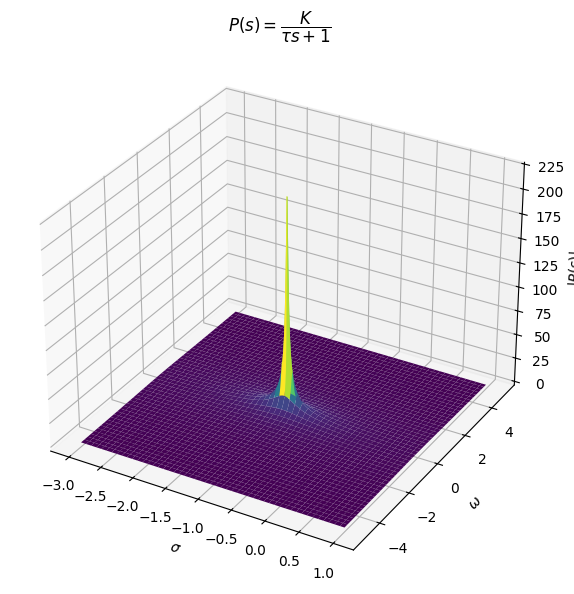

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
K = 4.0
tau = 1.0

# Create complex s-plane
sigma = np.linspace(-3, 1, 300)
omega = np.linspace(-5, 5, 300)

Sigma, Omega = np.meshgrid(sigma, omega)
S = Sigma + 1j * Omega

# Transfer function
P = K / (tau * S + 1)

# Magnitude
Z = np.abs(P)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    Sigma,
    Omega,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\omega$")
ax.set_zlabel(r"$|P(s)|$")
ax.set_title(r"$P(s)=\dfrac{K}{\tau s+1}$")

plt.show()

Now we're going to try to control this motor, and see how adding control moves the pole. For a negative feedback system, the transfer function is given by:
$$ G(s) = \dfrac{G_1(s)G_2(s)}{1 + G_1(s)G_2(s)}$$
Starting with a simple P controller, our controller would be a simple $u(t)$ = $K_p e$. Then:
$$ U(s) = K_p E(s) \Rightarrow G_c(s) = \dfrac{U(s)}{E(s)} = K_p $$
Substituting yields:
$$
\begin{align*}
G(s) & = \dfrac{P(s)G_c(s)}{1 + P(s)G_c(s)} \\
& = \dfrac{KK_p}{\tau s + 1 + KK_p}
\end{align*}
$$
We can see that two things happen here:

1. The pole moves to the left on the real axis. It moves from $s_1 = -\frac{1}{\tau}$ to $s_2 = -\frac{KK_p + 1}{\tau}$. This means that $s_2 < s_1$. The physical meaning is that for a negative real number $s$, the exponential $e^{st}$ models exponential decay. The lower $s$ is, the faster the decay, the quicker the system reaches steady state. Using the feedback controller we have achieved exactly this: larger $K_p$ means faster rise time.

2. We never reach the desired speed. The DC gain is $G(0) = \frac{KK_p}{1 + KK_p} < 1$, which means $\text{output}(s) < \text{input}(s)$ and $\lim_{K_p \rightarrow \infty} G(0) = 1$. Basically, we will always have a steady state error, and this error gets smaller as $K_p$ gets bigger.

These are basically what we observed while heuristically tuning our P controllers in earlier notebooks. But now that we can have a mathematical model for output versus input, we can confirm that: For all $s \in \mathbb{R}_{<0}$, the system will be stable, will not reach the desired output, and the rise time of the system scales as $s$ gets smaller. We make the pole $s$ become smaller by tuning a larger $K_p$. 

Graphically, the pole does move to the left:


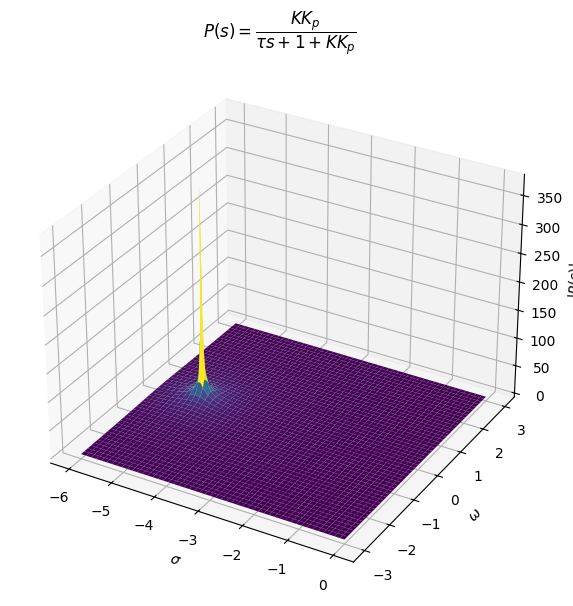

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
K = 4.0
tau = 1.0

Kp = 1.0

# Create complex s-plane
sigma = np.linspace(-6, 0, 300)
omega = np.linspace(-3, 3, 300)

Sigma, Omega = np.meshgrid(sigma, omega)
S = Sigma + 1j * Omega

# Transfer function
P = K * Kp / (tau * S + 1 + K * Kp)

# Magnitude
Z = np.abs(P)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    Sigma,
    Omega,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\omega$")
ax.set_zlabel(r"$|P(s)|$")
ax.set_title(r"$P(s)=\dfrac{KK_p}{\tau s+1+KK_p}$")

plt.show()

Now let's move to a PI controller, which is how we eliminated the steady state error. The transfer function of the controller is now
$$ G_c(s) = K_p + \dfrac{K_i}{s}$$
Using the same formula, we arrive at the transfer function of the system:
$$G(s) = \dfrac{K(K_p s + K_i)}{\tau s^2 + (KK_p + 1)s + K K_i}$$
We have:
- A zero at $s = -\frac{K_i}{K_p}$
- Two poles given by the quadratic formula
- A steady state $G(0) = 1$, meaning it matches the output


Let's first visualise it:

Zeros: [-5.]
Poles: [-1.5+2.78388218j -1.5-2.78388218j]


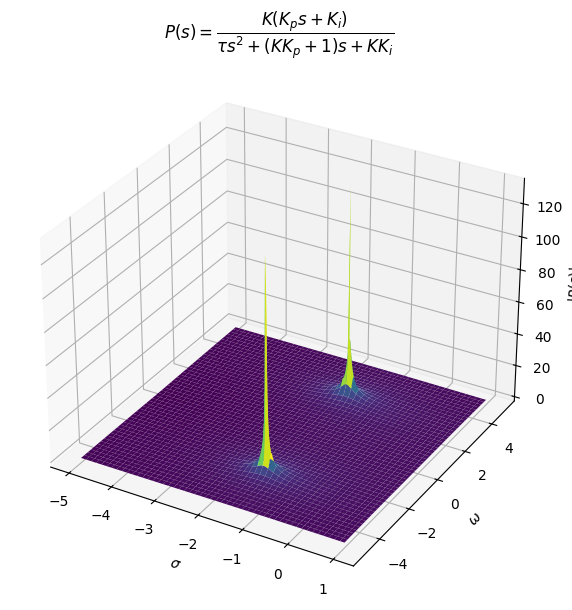

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
K = 2.0
tau = 1.0

Kp = 1.0
Ki = 5.0

# Create complex s-plane
sigma = np.linspace(-5, 1, 300)
omega = np.linspace(-5, 5, 300)

Sigma, Omega = np.meshgrid(sigma, omega)
S = Sigma + 1j * Omega

# Transfer function
P = K * (Kp * S + Ki) / (tau * S**2 + (1 + K * Kp) * S + K * Ki)

# Magnitude
Z = np.abs(P)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    Sigma,
    Omega,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\omega$")
ax.set_zlabel(r"$|P(s)|$")
ax.set_title(r"$P(s)=\dfrac{K(K_p s + K_i)}{\tau s^2 + (KK_p + 1)s + K K_i}$")

num = [K*Kp, K*Ki]
den = [tau, 1 + K*Kp, K*Ki]

zeros = np.roots(num)
poles = np.roots(den)

print("Zeros:", zeros)
print("Poles:", poles)

plt.show()

We know that every pole $s$ corresponds to a mode $e^{st}$. Naturally, we have two questions concerning the transfer function of the PI controller:
1. What is the physical meaning of a zero?
2. The quadratic can give complex values for poles. How can we interpret them?

Let's approach this by converting the transfer function back to the time domain. Call the two poles $p_1$ and $p_2$, we can use partial fractions:
$$G(s) = \dfrac{K(K_p s + K_i)}{\tau(s - p_1)(s-p_2)} = \dfrac{A}{s-p_1} + \dfrac{B}{s-p_2}$$
Solving for $A$ and $B$ yields;
$$ G(s) = \dfrac{K(K_p p_1 + K_i)}{\tau (p_1 - p_2)} \dfrac{1}{s-p_1} + \dfrac{K(K_p p_2 + K_i)}{\tau (p_1 - p_2)} \dfrac{1}{s-p_2}$$
Taking the inverse Laplace transform, we yield the time domain response:
$$ g(t) = \dfrac{K(K_p p_1 + K_i)}{\tau (p_1 - p_2)} e^{p_1 t} + \dfrac{K(K_p p_2 + K_i)}{\tau (p_1 - p_2)}e^{p_2 t}$$

From this we have several observations:
- The shape of the response is a weighted sum of two exponentials $Ae^{p_1 t} + Be^{p_2 t}$. The PI gains in the denominator change the pole locations, and in the denominator change the zero locations, which in turn change the weight. Zero placement affects the coefficients $A$ and $B$, therefore exciting or dampening a certain natural mode.
- Physically, at zero of a transfer function, the dynamics "mute" a certain complex frequency. For example, a zero at $s = 0$ means the system doesn't respond to a constant DC signal.
- If a zero is very near a pole, the weight of that pole becomes very small. The dynamics are cancelled out.

We come to the conclusion: a pole determines the modes of behaviour of a system. A zero determines how the input excites or suppresses those modes.



Okay but the pole placement here is a bit different. Unlike the first order response where the pole lies on $\Re (s)$, the roots of a quadratic can lie anywhere on the complex plane. We already know that if $s = \sigma < 0$ then the system is stable with a decay mode, and if $s = \sigma > 0$ then the system is unstable and it blows up to infinity. For other cases:
- If $s = j \omega$, $e^{st}$ is a pure sinusoid.
- If $s = \sigma + j \omega$ with $\sigma < 0$, the system oscillates and decay.
- If $s = \sigma + j \omega$ with $\sigma > 0$, the system oscillates and blows up.
Let's analyse the poles of our PI controller. Consider the transfer function:
$$G(s) = \dfrac{K(K_p s + K_i)}{\tau s^2 + (KK_p + 1)s + K K_i}$$
Let's consider the discriminant:
$$ \Delta = (1 + KK_p)^2 - 4\tau KK_i$$
There are 3 cases, similar to how one would understand a harmonic oscillator:
1. $\Delta > 0$

We have two distinct real poles. Using Vietà's formula, we also know that these two poles are negative. The system then is called "overdamped". There is no oscillation, but the system settles slower.

2. $\Delta < 0$

Two complex conjugate poles mean that there are two oscillation modes. There can be overshoot, there can be ringing, and the system oscillates before settling.

3. $\Delta = 0$

This is the optimal state, called "critically damped". When $\Delta = 0$, the transfer function is
$$G(s) = \dfrac{A}{(s-p)^2}$$
The repeated pole produces the response $te^{pt}$, which decays at the same exponential rate $e^{pt}$ but initially grows because of the polynomial factor $t$. This gives the fastest possible non-oscillatory response, known as critical damping.

To better understand the dynamics of the second order system and to tune our PI controller, we can write the denominator as
$$ s^2 + 2 \zeta \omega _n s + \omega _n^2$$
This work under the substitution
$$\omega _n = \sqrt{\dfrac{KK_i}{\tau}} \hspace{50pt} \zeta = \dfrac{1 + KK_p}{2\sqrt{\tau KK_i}}$$
From this, by matching coefficients, we can optimally tune for the behaviour we want. Need rise time? Increase $K_i$. What's the peak time? That's just $t_p = \frac{\pi}{\omega _n \sqrt{1-\zeta^2}}$. How much overshoot? Exactly $e^{-\frac{\pi \zeta}{\sqrt{1-\zeta^2}}}$. How long does it take for the system to settle? $t_s \approx \frac{4}{\zeta \omega _n}$. 

Basically, knowing the damping term $\zeta$ and the natural frequency of the system $\omega _n$, we can know lots of things about the system, and control it accordingly. First order systems and second order systems, given LTI, are completely solveable.

Although real systems are often much higher order, the poles closest to the imaginary axis decay the slowest and therefore dominate the transient response. Engineers often approximate complicated systems by keeping only these dominant poles, reducing them to an equivalent first- or second-order model.

But now we can move on to the full PID controller. Then, the transfer function of the controller is
$$ G_c(s) = \dfrac{K_d s^2 + K_p s + K_i}{s}$$
The full controller of the plant is given by:
$$ G(s) = \dfrac{K(K_d s^2 + K_p s + K_i)}{(\tau + KK_d)s^2 + (KK_p + 1)s + KK_i}$$

Notice how we obtain the same shape. The truth is, for simple first-order plants, PI control is often sufficient because it already allows independent tuning of the dominant second-order closed-loop poles (speed and damping). The derivative term becomes valuable when higher-order dynamics, disturbances, measurement delays, or aggressive transient performance require additional damping and phase lead. Its main contribution is not increasing the order of the system, but providing extra freedom through the numerator zeros and improving robustness to non-ideal dynamics.

If the plant is well approximated as first order and disturbances are moderate, the extra complexity and noise sensitivity of the derivative term often isn't worth the modest improvement. We have now reached the limits of what can be achieved by studying only first- and second-order transfer functions. Fortunately, many practical systems are well approximated by these models, and even higher-order systems are often dominated by one or two poles. This is why the concepts of pole location, damping ratio, and natural frequency remain the foundation of classical control design.


We have now developed a complete understanding of classical first- and second-order linear systems. By studying the poles of the closed-loop transfer function, we can predict stability, rise time, settling time, overshoot, oscillation, and steady-state error without repeatedly solving differential equations. Controller tuning therefore becomes a process of placing poles and zeros in desirable locations rather than trial and error. Although practical systems are often much higher order, their behaviour is frequently dominated by only a few poles, allowing the same ideas to remain remarkably effective. So we can say, **problem solved**.